In [131]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/comment-category-prediction-challenge/Sample.csv
/kaggle/input/comment-category-prediction-challenge/train.csv
/kaggle/input/comment-category-prediction-challenge/test.csv


In [132]:
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MaxAbsScaler ,MinMaxScaler , OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, RandomizedSearchCV 
from sklearn.svm import LinearSVC
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import VotingClassifier


# DATA LOADING

In [133]:
df = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")

In [134]:
df.shape

(198000, 15)

In [135]:
X_test = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/test.csv")

X_test.shape

(102000, 14)

In [136]:
print(df["label"].unique())

[2 0 1 3]


In [137]:
X = df.drop("label", axis=1)
y = df["label"]

In [138]:
X.head()

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,NaN,NaN,NaN,False,She might be a bright spot for a party keou on...
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,NaN,NaN,NaN,False,"Under Alaska law, a non-tribal member is not b..."
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,NaN,NaN,NaN,False,in the future please spare me your strawman dr...
3,2023-05-28 22:00:14.214527+00:00,39,0,0,0,5,0,0,10,NaN,NaN,NaN,False,"PS: That should have been ""rot"" instead of ""co..."
4,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0,0,0,10,NaN,NaN,NaN,False,"Today, the confederate flag...tomorrow, the na..."


In [139]:
# model = DummyClassifier()
# model.fit(X,y)
# y_predict= model.predict(X_test)

In [140]:
# submission = pd.DataFrame({'ID': range(1,X_test.shape[0]+1),
#                             'target':y_predict})
# submission.to_csv("submission.csv", index= False)

# **Milestone 1 Code**

In [141]:
print("Shape of training Dataset:",df.shape)

Shape of training Dataset: (198000, 15)


In [142]:
col= X_test.shape[1]
print("Total no of columns in test dataset:", col)

Total no of columns in test dataset: 14


In [143]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198000 entries, 0 to 197999
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  198000 non-null  object
 1   post_id       198000 non-null  int64 
 2   emoticon_1    198000 non-null  int64 
 3   emoticon_2    198000 non-null  int64 
 4   emoticon_3    198000 non-null  int64 
 5   upvote        198000 non-null  int64 
 6   downvote      198000 non-null  int64 
 7   if_1          198000 non-null  int64 
 8   if_2          198000 non-null  int64 
 9   race          52577 non-null   object
 10  religion      52577 non-null   object
 11  gender        52577 non-null   object
 12  disability    198000 non-null  bool  
 13  comment       197999 non-null  object
 14  label         198000 non-null  int64 
dtypes: bool(1), int64(9), object(5)
memory usage: 21.3+ MB


In [144]:
# X_test.info()
obj_col = (df.dtypes == "object").sum()
print("No of column having object datatype:", obj_col)

No of column having object datatype: 5


In [145]:
int_col =(df.dtypes== "int64").sum()
print("No of column having int datatype:", int_col)


No of column having int datatype: 9


In [146]:
bool_col =df.select_dtypes(include ="bool").columns.to_list()


if len(bool_col)==1:
    print("The column having boolean datatype is",bool_col[0])
else:
    print("The column having boolean datatype is ",bool_col)
    


The column having boolean datatype is disability


In [147]:
miss_col = df.isnull().sum()
miss_col

print("Columns having missing values are")
for col, val in miss_col.items():
    if val!= 0:
        print(col)

Columns having missing values are
race
religion
gender
comment


In [148]:
print("Total distinct target classes :",len(df["label"].unique()))

Total distinct target classes : 4


In [149]:
label_0= df["label"].value_counts()
label_0
label_0_percentage= (label_0[0]/ df.shape[0])*100
print(label_0_percentage)

57.66313131313131


In [150]:
upvote_med= df["upvote"].median()
print("Median value of upvote: ", upvote_med)

Median value of upvote:  1.0


In [151]:
df.describe()

,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,label
count,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000
mean,68.447429,0.279768,0.048338,0.121071,2.607975,0.666394,1.906152,7.956212,0.793965
std,27.948390,1.023234,0.258477,0.481013,5.054763,2.044335,25.635752,14.839464,0.979808
min,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000
25%,39.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,0.000000
50%,72.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,6.000000,0.000000
75%,72.000000,0.000000,0.000000,0.000000,3.000000,1.000000,4.000000,10.000000,2.000000
max,129.000000,47.000000,11.000000,17.000000,201.000000,107.000000,1860.000000,1833.000000,3.000000



# EDA(Exploratory Data Analysis)

In [152]:
df.shape

(198000, 15)

In [153]:
df.columns

Index(['created_date', 'post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3',
       'upvote', 'downvote', 'if_1', 'if_2', 'race', 'religion', 'gender',
       'disability', 'comment', 'label'],
      dtype='object')

In [154]:
X_test.columns

Index(['created_date', 'post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3',
       'upvote', 'downvote', 'if_1', 'if_2', 'race', 'religion', 'gender',
       'disability', 'comment'],
      dtype='object')

In [155]:
df.head()

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,NaN,NaN,NaN,False,She might be a bright spot for a party keou on...,2
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,NaN,NaN,NaN,False,"Under Alaska law, a non-tribal member is not b...",0
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,NaN,NaN,NaN,False,in the future please spare me your strawman dr...,2
3,2023-05-28 22:00:14.214527+00:00,39,0,0,0,5,0,0,10,NaN,NaN,NaN,False,"PS: That should have been ""rot"" instead of ""co...",2
4,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0,0,0,10,NaN,NaN,NaN,False,"Today, the confederate flag...tomorrow, the na...",2


In [156]:
df.describe()

,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,label
count,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000
mean,68.447429,0.279768,0.048338,0.121071,2.607975,0.666394,1.906152,7.956212,0.793965
std,27.948390,1.023234,0.258477,0.481013,5.054763,2.044335,25.635752,14.839464,0.979808
min,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000
25%,39.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,0.000000
50%,72.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,6.000000,0.000000
75%,72.000000,0.000000,0.000000,0.000000,3.000000,1.000000,4.000000,10.000000,2.000000
max,129.000000,47.000000,11.000000,17.000000,201.000000,107.000000,1860.000000,1833.000000,3.000000


In [157]:
df.describe(include ='object')

,created_date,race,religion,gender,comment
count,198000,52577,52577,52577,197999
unique,197996,6,8,5,197842
top,2022-05-06 20:47:06.726636+00:00,none,none,none,Exactly..
freq,2,39682,38249,36161,8


In [158]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198000 entries, 0 to 197999
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  198000 non-null  object
 1   post_id       198000 non-null  int64 
 2   emoticon_1    198000 non-null  int64 
 3   emoticon_2    198000 non-null  int64 
 4   emoticon_3    198000 non-null  int64 
 5   upvote        198000 non-null  int64 
 6   downvote      198000 non-null  int64 
 7   if_1          198000 non-null  int64 
 8   if_2          198000 non-null  int64 
 9   race          52577 non-null   object
 10  religion      52577 non-null   object
 11  gender        52577 non-null   object
 12  disability    198000 non-null  bool  
 13  comment       197999 non-null  object
 14  label         198000 non-null  int64 
dtypes: bool(1), int64(9), object(5)
memory usage: 21.3+ MB


In [159]:
X_test.describe()

,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2
count,102000.000000,102000.000000,102000.000000,102000.000000,102000.000000,102000.000000,102000.000000,102000.000000
mean,68.359422,0.280078,0.048353,0.118902,2.609402,0.661667,1.903078,7.956206
std,27.923491,1.043353,0.257278,0.480484,4.966033,1.965536,26.273483,15.186746
min,24.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000
25%,39.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000
50%,72.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,6.000000
75%,72.000000,0.000000,0.000000,0.000000,3.000000,1.000000,4.000000,10.000000
max,129.000000,95.000000,8.000000,19.000000,189.000000,95.000000,1866.000000,1798.000000


In [160]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102000 entries, 0 to 101999
Data columns (total 14 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  102000 non-null  object
 1   post_id       102000 non-null  int64 
 2   emoticon_1    102000 non-null  int64 
 3   emoticon_2    102000 non-null  int64 
 4   emoticon_3    102000 non-null  int64 
 5   upvote        102000 non-null  int64 
 6   downvote      102000 non-null  int64 
 7   if_1          102000 non-null  int64 
 8   if_2          102000 non-null  int64 
 9   race          26731 non-null   object
 10  religion      26731 non-null   object
 11  gender        26731 non-null   object
 12  disability    102000 non-null  bool  
 13  comment       102000 non-null  object
dtypes: bool(1), int64(8), object(5)
memory usage: 10.2+ MB


## Missing values 

In [161]:
missing_count = (df.isnull().sum())


In [162]:
missing_percentage = (df.isnull().sum()/len(df))* 100

In [163]:
missing_table =pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage": missing_percentage
})
missing_table = missing_table.sort_values("Missing Percentage", ascending =False)
missing_table


,Missing Count,Missing Percentage
gender,145423,73.445960
race,145423,73.445960
religion,145423,73.445960
comment,1,0.000505
created_date,0,0.000000
post_id,0,0.000000
emoticon_1,0,0.000000
downvote,0,0.000000
upvote,0,0.000000
emoticon_3,0,0.000000


#### I observed that the feature ***gender, race, religion*** contain very high missing values(***145423***), which corresponds to ***73.45%*** of the dataset.It concludes that most records don't have information for these features.

#### The comment column has only ***1 missing values(0.000505)*** which can be handles by simply removing the row.

#### Rest of the features has no missing values

In [164]:
X_test.isnull().sum()

created_date        0
post_id             0
emoticon_1          0
emoticon_2          0
emoticon_3          0
upvote              0
downvote            0
if_1                0
if_2                0
race            75269
religion        75269
gender          75269
disability          0
comment             0
dtype: int64

In [165]:
df["label"].value_counts()


label
0    114173
2     62440
1     15918
3      5469
Name: count, dtype: int64

In [166]:
 label_percentage=df["label"].value_counts(normalize=True)*100

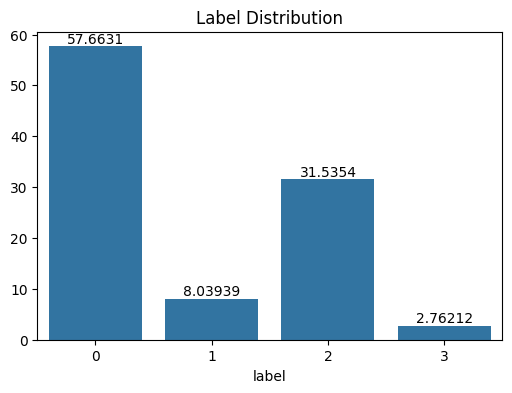

In [167]:
plt.figure(figsize =(6,4))
length = len(df)

ax = sns.barplot(x= label_percentage.index , y= label_percentage.values)

plt.title("Label Distribution")

for container in ax.containers:
    ax.bar_label(container)
plt.show()

#### It is observed that most of the comments belong to label-0 i.e 57.6631% of total comments.
#### Next label-2 is the second highest with 31.5354% followed by label-1 with 8.03939% and *label-3 2.76212%*

#### The target variable is highly imbalanced, with a strong dominance of Label 0, which may bias the model and negatively impact the prediction of minority classes.


## Categorical Column Distribution 


In [168]:
race_val = df["race"].unique()
race_val
df["race"].value_counts()

race
none      39682
white      5486
black      3869
other      1654
asian      1263
latino      623
Name: count, dtype: int64

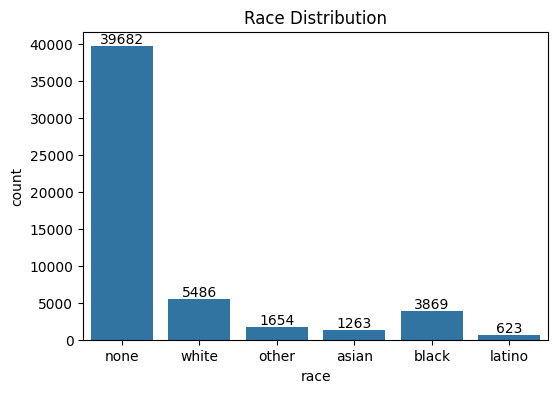

In [169]:
plt.figure(figsize=(6,4))
ax = sns.countplot(x = "race" , data = df)
plt.title("Race Distribution")
for container in ax.containers:
     ax.bar_label(container)
plt.show()

#### The race feature shows a highly imbalanced distribution, with the majority of values categorized as "none", indicating missing or unspecified data. This imbalance may introduce bias in the model and reduce the effectiveness of this feature for prediction. Minority categories such as Latino and Asian are underrepresented, which may limit the model's ability to generalize across different groups.

In [170]:
religion_val = df["religion"].unique()
religion_val


array([nan, 'christian', 'muslim', 'none', 'jewish', 'atheist', 'other',
       'hindu', 'buddhist'], dtype=object)

In [171]:
df["religion"].value_counts()

religion
none         38249
christian     7191
muslim        4930
jewish        1244
other          547
atheist        219
buddhist       100
hindu           97
Name: count, dtype: int64

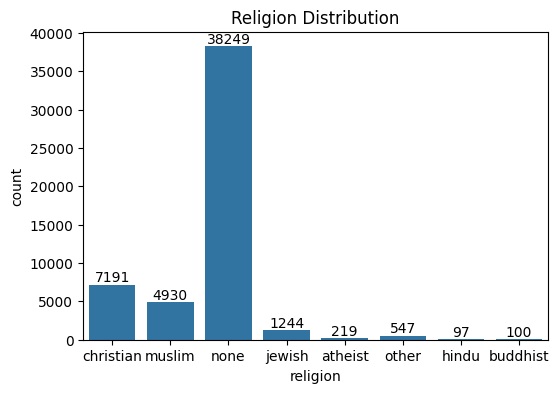

In [172]:
plt.figure(figsize=(6,4))
ax = sns.countplot(x = "religion" , data = df)
plt.title("Religion Distribution")
for container in ax.containers:
     ax.bar_label(container)
plt.show()

#### The religion feature is dominated by missing/unspecified values and shows strong class imbalance, which may reduce its effectiveness in model prediction.

In [173]:
gender_val = df["gender"].unique()
gender_val

array([nan, 'none', 'male', 'female', 'transgender', 'other'],
      dtype=object)

In [174]:
df["gender"].value_counts()

gender
none           36161
female          8037
male            7549
transgender      622
other            208
Name: count, dtype: int64

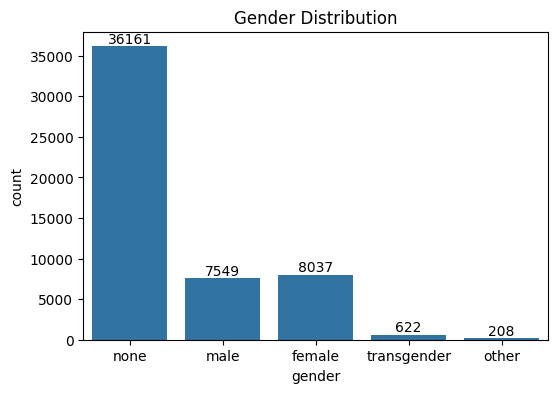

In [175]:
plt.figure(figsize=(6,4))
ax = sns.countplot(x = "gender" , data = df)
plt.title("Gender Distribution")
for container in ax.containers:
     ax.bar_label(container)
plt.show()

#### The religion feature exhibits a highly imbalanced distribution, with the majority of values categorized as "none", indicating missing or unspecified data. Minority categories such as Hindu, Buddhist, and Atheist have very low representation, which may limit the model’s ability to learn meaningful patterns. This imbalance may introduce bias and reduce the predictive effectiveness of the feature.



In [176]:
df["disability"].value_counts()

disability
False    195257
True       2743
Name: count, dtype: int64

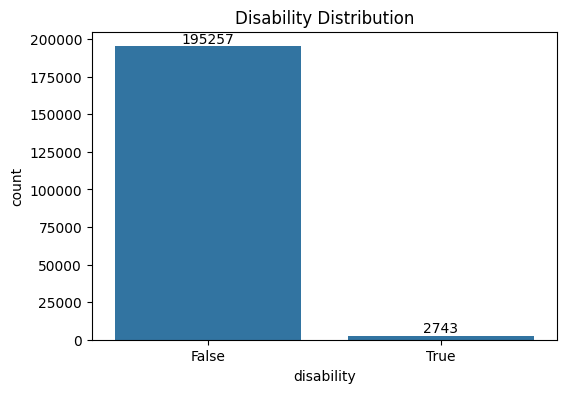

In [177]:
plt.figure(figsize=(6,4))
ax = sns.countplot(x = "disability" , data = df)
plt.title("Disability Distribution")
for container in ax.containers:
     ax.bar_label(container)
plt.show()

#### The disability feature is highly imbalanced, with very few positive cases, which may limit its contribution to the model and require careful handling to avoid bias.

## Numeric Column Distribution

In [178]:
df["post_id"].value_counts()

post_id
72     69529
39     40946
120    24324
31     17023
73     14882
71     13308
40      5488
123     4809
118     2692
61      1149
24      1080
84       915
111      351
70       208
105      165
91       156
64       141
102      121
85       104
103       73
77        57
115       50
87        44
100       40
93        37
83        30
76        25
75        25
89        23
90        22
104       21
101       18
109       16
79        13
96        13
50        13
129       12
42        11
74        10
82        10
43        10
86         7
95         6
66         6
88         4
67         4
108        2
125        2
110        2
20         1
113        1
65         1
Name: count, dtype: int64

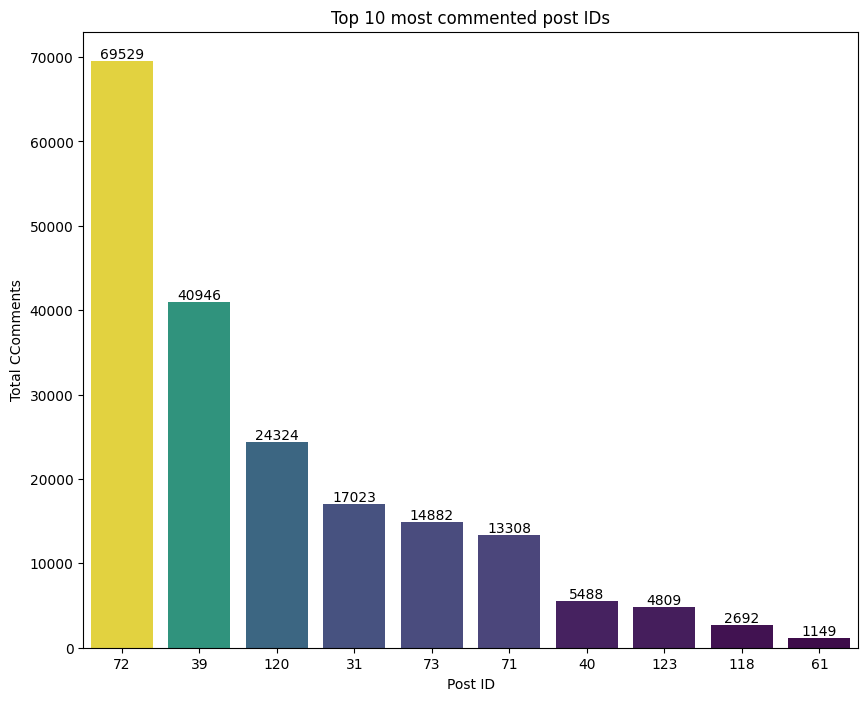

In [179]:
top10_post = df["post_id"].value_counts().head(10).sort_values(ascending = False)
plt.figure(figsize=(10,8))
ax = sns.barplot(x= top10_post.index, y= top10_post.values, order=top10_post.index,hue= top10_post.values, palette="viridis", legend =False)
plt.title("Top 10 most commented post IDs")
plt.xlabel("Post ID")
plt.ylabel("Total CComments")

for container in ax.containers:
    ax.bar_label(container)
plt.show()

#### Here is the top 10 most commented post ids and it is observed that post id 72 has highest no of comments

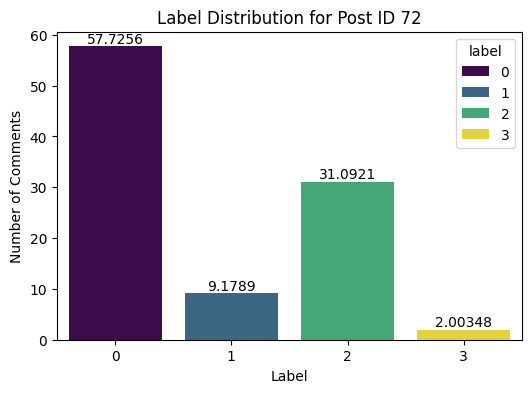

In [180]:
post72 = df[df["post_id"]== 72]["label"].value_counts(normalize=True)*100
plt.figure(figsize=(6,4))

ax = sns.barplot(
    x=post72.index,
    y=post72.values,
    palette="viridis",
    hue = post72.index
)
plt.title("Label Distribution for Post ID 72")
plt.xlabel("Label")
plt.ylabel("Number of Comments")
for container in ax.containers:
    ax.bar_label(container)
plt.show()    
    

#### Even in highly commented posts, the label distribution remains imbalanced with dominance of Label 0, indicating consistent commenting behavior across the dataset.

#### i.e High engagement (more comments) does not necessarily increase minority or extreme label categories, suggesting that comment volume is not strongly correlated with label diversity.


In [181]:
df["emoticon_1"].value_counts()


emoticon_1
0     169078
1      17683
2       5799
3       2362
4       1243
5        638
6        374
7        225
8        162
9        102
10        69
11        68
12        40
13        27
15        20
16        20
14        19
19        13
17         9
23         7
22         6
20         5
18         5
36         4
25         4
27         3
24         2
21         2
31         2
30         2
32         2
28         1
46         1
33         1
47         1
39         1
Name: count, dtype: int64

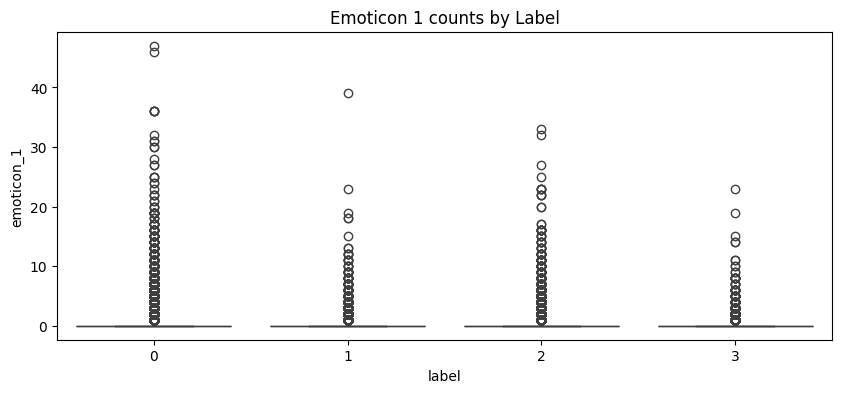

In [182]:
plt.figure(figsize=(10,4))
sns.boxplot(x='label', y='emoticon_1', data=df)
plt.title("Emoticon 1 counts by Label")
plt.show()

#### Most values of emoticon_1 are 0 across all labels, indicating that many comments do not use this emoticon.

#### All labels show a similar distribution pattern, meaning no strong separation between classes.

#### There are outliers in all labels, showing that some comments have high emoticon usage.

#### Label 0 and Label 2 show slightly higher spread compared to others.

#### Label 3 has fewer data points and lower variation.

In [183]:
df["emoticon_2"].value_counts()


emoticon_2
0     189891
1       7031
2        822
3        177
4         48
5         21
6          7
8          1
11         1
7          1
Name: count, dtype: int64

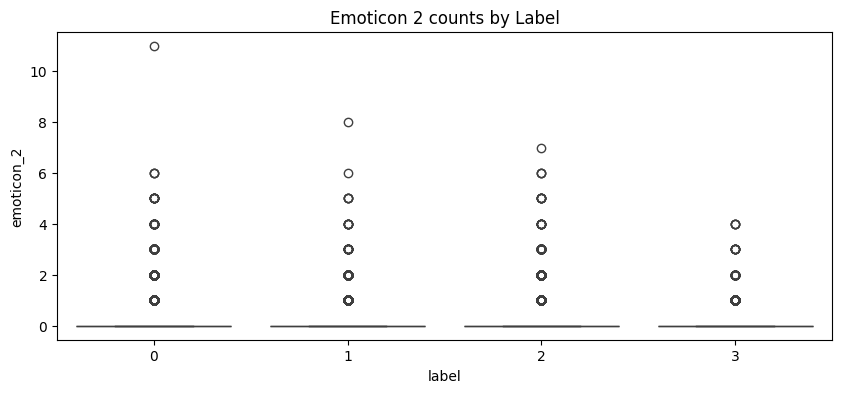

In [184]:
plt.figure(figsize=(10,4))
sns.boxplot(x='label', y='emoticon_2', data=df)
plt.title("Emoticon 2 counts by Label")
plt.show()

#### Most values of emoticon_2 are 0 across all labels, indicating low usage overall.

#### The distribution across labels is very similar, with no clear separation.

#### Label 0 shows the highest outliers, indicating occasional higher emoticon usage.

#### Label 3 has the least variation and lowest counts.

#### Overall, emoticon usage is sparse and inconsistent.

#### Emoticon_2 shows low and similar usage across all labels, making it a weak individual predictor for classification


In [185]:
df["emoticon_3"].value_counts()

emoticon_3
0     180835
1      13017
2       2777
3        764
4        309
5        132
6         79
7         41
8         14
10        12
9          9
11         4
14         2
13         2
12         2
17         1
Name: count, dtype: int64

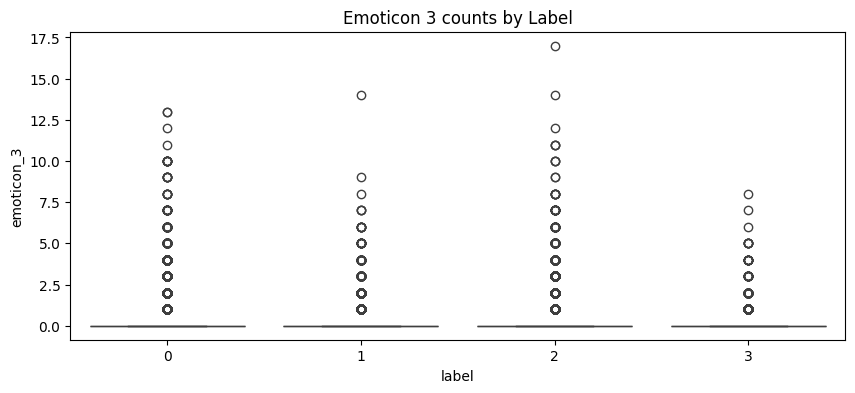

In [186]:

plt.figure(figsize=(10,4))
sns.boxplot(x='label', y='emoticon_3', data=df)
plt.title("Emoticon 3 counts by Label")
plt.show()

#### Most values of emoticon_3 are 0 across all labels, indicating low overall usage.

#### The distributions across all labels are very similar, with no clear separation.

#### Label 2 shows slightly higher variation and higher outliers compared to others.

#### Label 3 has the lowest spread and fewer data points.

#### Presence of outliers indicates occasional high emoticon usage, but not consistent.

#### Emoticon_3 shows sparse and similar usage across labels, making it a weak standalone feature for classification.


In [187]:
df["upvote"].describe()

count    198000.000000
mean          2.607975
std           5.054763
min           0.000000
25%           0.000000
50%           1.000000
75%           3.000000
max         201.000000
Name: upvote, dtype: float64

#### From this analysis for upvote we can conclude as follows:
##### **mean**:~ 2.6 i.e most comments get very few upvotes
##### **Median** : 1 i.e half the comments have <=1 upvote.
##### **75th percentile** : 3 i.e 75% of comments have <= 3 upvotes
##### **Max** : 201 i.e a few comments are extremely popular

##### **Skewed distribution**: Most comments have low upvotes, but a tiny fraction have very high values (long-tailed / right-skewed distribution)

In [188]:
df.groupby('label')['upvote'].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,114173.0,2.404833,4.601209,0.0,0.0,1.0,3.0,201.0
1,15918.0,2.850107,6.047758,0.0,0.0,1.0,3.0,166.0
2,62440.0,2.967825,5.612198,0.0,0.0,1.0,4.0,163.0
3,5469.0,2.035656,3.765532,0.0,0.0,1.0,2.0,44.0


In [189]:
df["downvote"].describe()

count    198000.000000
mean          0.666394
std           2.044335
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max         107.000000
Name: downvote, dtype: float64

#### From this analysis for upvote we can conclude as follows:
##### **mean**:~ 0.6 i.e most comments get very less downvotes
##### **Median** : 0 i.e half the comments have 0 downvotes.
##### **75th percentile** : 3 i.e 75% of comments have <= 1 downvotes
##### **Max** : 107 i.e a few comments are heavily downvoted

##### **Skewed distribution**: Most comments have low downvotes, but a tiny fraction have very high values (extremely long-tailed / right-skewed distribution)

In [190]:
df.groupby('label')['downvote'].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,114173.0,0.575294,1.863328,0.0,0.0,0.0,0.0,101.0
1,15918.0,0.802048,2.171240,0.0,0.0,0.0,1.0,68.0
2,62440.0,0.811723,2.336218,0.0,0.0,0.0,1.0,107.0
3,5469.0,0.514171,1.517042,0.0,0.0,0.0,0.0,26.0


In [191]:
df["if_1"].value_counts()

if_1
0       145423
4        31061
10       11849
6         6774
5         2691
7           70
9           45
11          32
12           2
1814         2
1545         2
1783         2
8            2
1551         2
249          1
1569         1
1800         1
1560         1
1263         1
1267         1
1258         1
1543         1
250          1
1815         1
1538         1
1585         1
1830         1
1277         1
1807         1
1810         1
1777         1
1848         1
1257         1
1548         1
1232         1
1583         1
1572         1
1576         1
1256         1
1566         1
1547         1
1825         1
1271         1
1838         1
1553         1
1846         1
1558         1
1557         1
1767         1
1819         1
1581         1
1254         1
1811         1
1860         1
1778         1
1827         1
1584         1
Name: count, dtype: int64

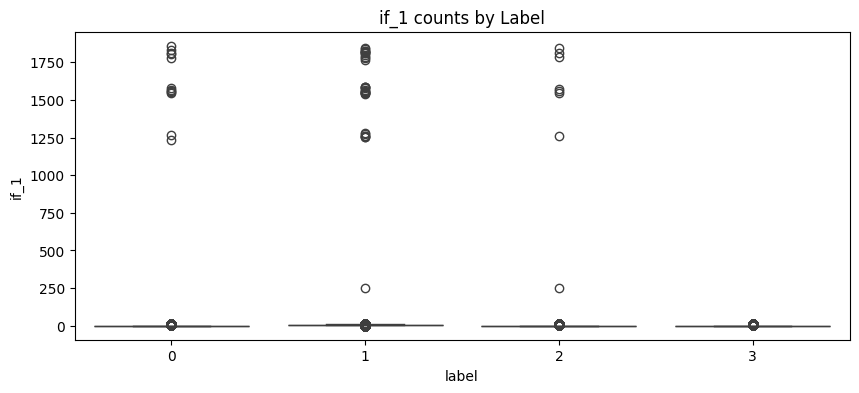

In [192]:
plt.figure(figsize=(10,4))
sns.boxplot(x='label', y='if_1', data=df)
plt.title("if_1 counts by Label")
plt.show()

#### Most values of if_1 are very low (close to 0) across all labels.

#### There are extreme outliers (very high values) present in Labels 0, 1, and 2.

#### Label 3 shows very low variation and almost no extreme values.

#### The overall distribution is highly skewed (long-tail).


#### So we can conclude if_1 feature is highly skewed with extreme outliers and limited separation across labels, though high-value outliers may provide some predictive signal.


In [193]:
df["if_2"].value_counts()

if_2
4       91726
10      80693
6       14558
5        6188
70        453
        ...  
1694        1
1527        1
1071        1
110         1
1171        1
Name: count, Length: 81, dtype: int64

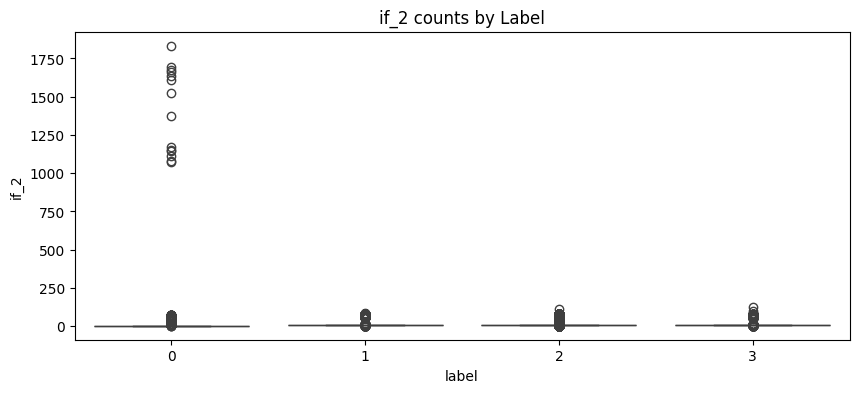

In [194]:
plt.figure(figsize=(10,4))
sns.boxplot(x='label', y='if_2', data=df)
plt.title("if_2 counts by Label")
plt.show()

#### From this we can observe that for high value of if_2 (nearly more than 250) model will almost predict label as 0 
#### At the other hand for low value it will be difficult to conclude the label as they don't have any triggered element.

## Correlation among the features

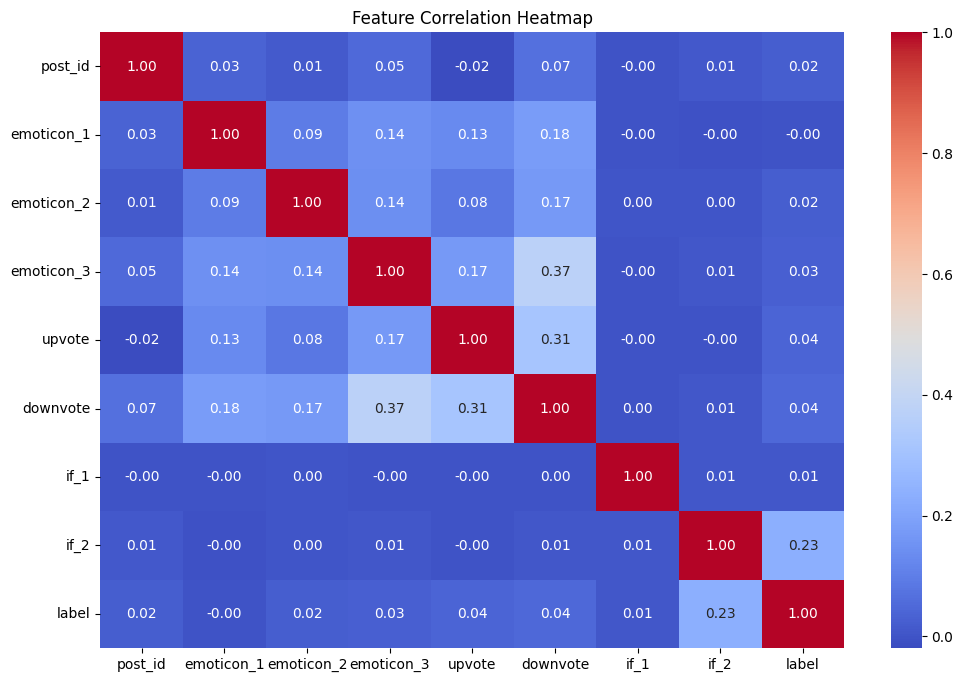

In [195]:
numeric_col = df.select_dtypes(include=['number'])
plt.figure(figsize=(12, 8))
sns.heatmap(numeric_col.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Feature Correlation Heatmap")
plt.show()

#### From this heat map we can conclude as follows:
#### if_2 shows 0.23 correlation with the label while if_1 shows almost 0 i.e 0.01 , suggesting it might just be a noise.

#### emoticon_3 and downvotes are strongly related(0.37) i.e emoticon_3 is higly associated with negative sentiments

#### upvotes and downvotes correlate with each other (0.31), confirming that the most positive commented post also get equally negative commnts.

#### Since post_id has nearly zero correlation with the target, the category depends on what is being said, rather than where it was posted.

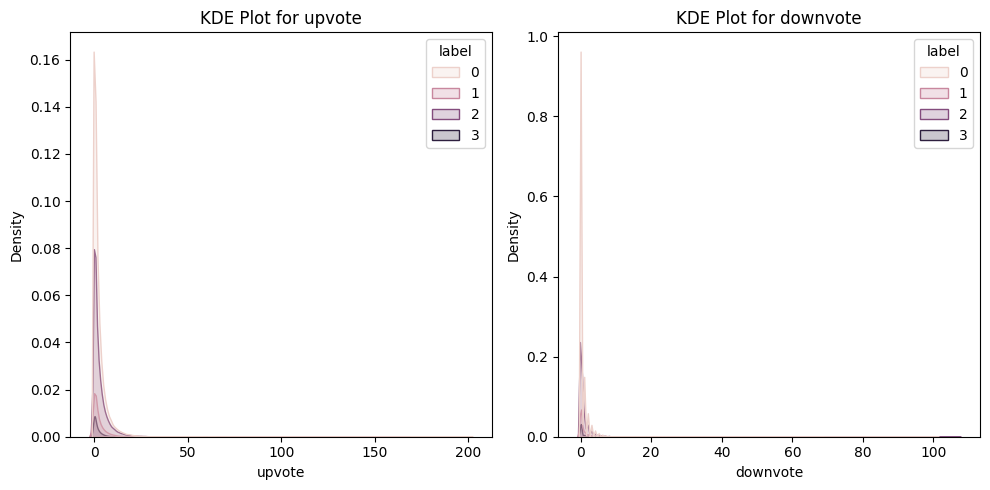

In [196]:

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(10,5))

sns.kdeplot(data=df, x= "upvote", hue="label", fill= True, ax= ax1)
ax1.set_title("KDE Plot for upvote")

sns.kdeplot(data=df, x= "downvote", hue="label", fill= True, ax=ax2)
ax2.set_title("KDE Plot for downvote")

plt.tight_layout()
plt.show()

#### Both upvote and downvote features are sparse and skewed.

#### They do not clearly differentiate labels on their own.

#### Extreme values (very high votes) may carry some signal, but rare.

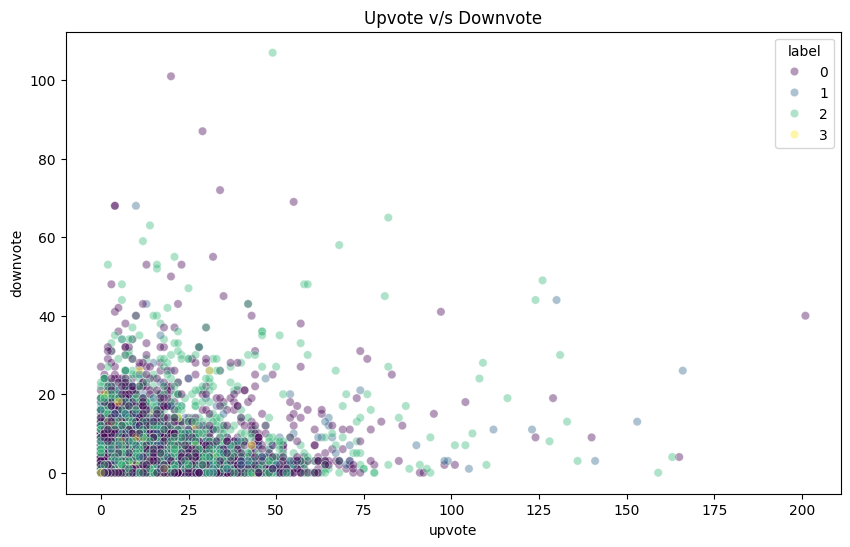

In [197]:
plt.figure(figsize=(10,6))
sns.scatterplot(data= df, x= "upvote", y="downvote" , palette="viridis", alpha=0.4, hue="label")
plt.title("Upvote v/s Downvote")
plt.show()

#### There is no strong linear relationship between upvotes and downvotes.

#### Upvote and downvote values show high overlap and weak correlation, indicating limited effectiveness in separating different labels.

## RACE V/S LABEL

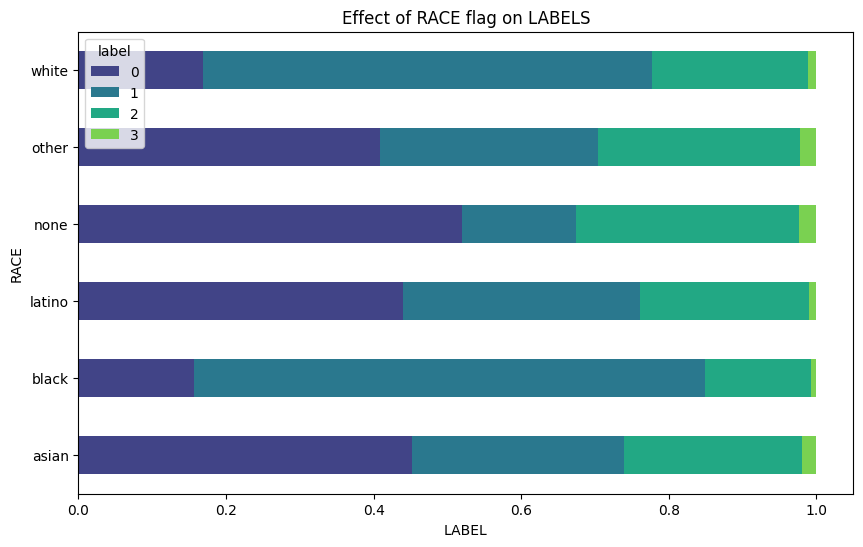

In [198]:
race_label = pd.crosstab(df["race"], df["label"], normalize="index")
race_label.plot(kind="barh", stacked= True, figsize= (10,6), color=sns.color_palette("viridis", 4))
plt.title("Effect of RACE flag on LABELS")
plt.xlabel("LABEL")
plt.ylabel("RACE")
plt.xticks(rotation=0)
plt.show()

#### Label distribution varies across race categories, indicating some influence of race on labels.

#### Label 0 dominates in most race groups, especially for none and latino.

#### Label 1 is higher for "white" and "black" categories, compared to others.

#### Label 2 is relatively consistent across all races, showing stable behavior.

#### Label 3 is very low across all categories, indicating it is rare regardless of race.

#### Race shows slight variation in label distribution, indicating moderate influence on prediction but not a strong distinguishing feature.


## RELIGION V/S LABEL

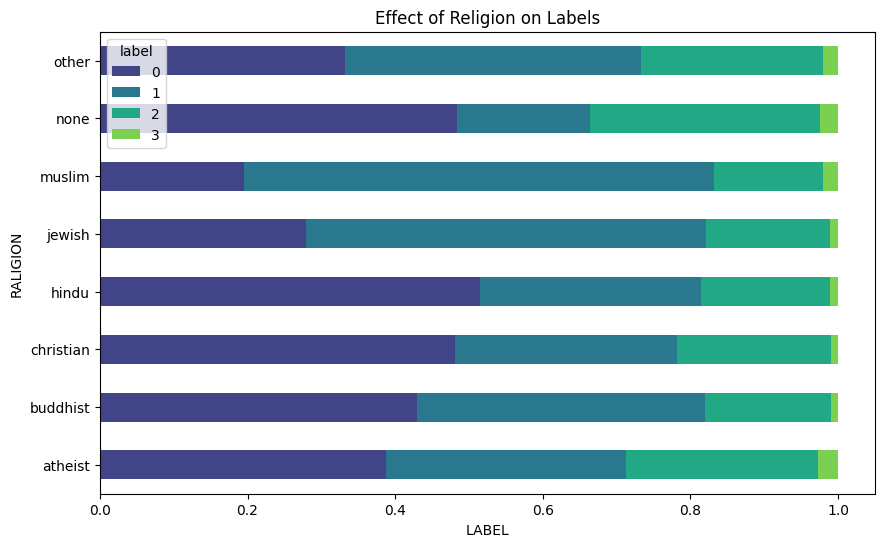

In [199]:
religion_label = pd.crosstab(df["religion"], df["label"], normalize="index")
religion_label.plot(kind="barh", stacked= True, figsize= (10,6), color=sns.color_palette("viridis", 4))
plt.title("Effect of Religion on Labels")
plt.xlabel("LABEL")
plt.ylabel("RALIGION")
plt.xticks(rotation=0)
plt.show()

#### Religion is a useful but sensitive feature

#### There is clear variation in label distribution across categories

#### Strong class imbalance exists

#### Some categories are more predictive than others

#### Rare labels need special handling

## GENDER V/S LABEL

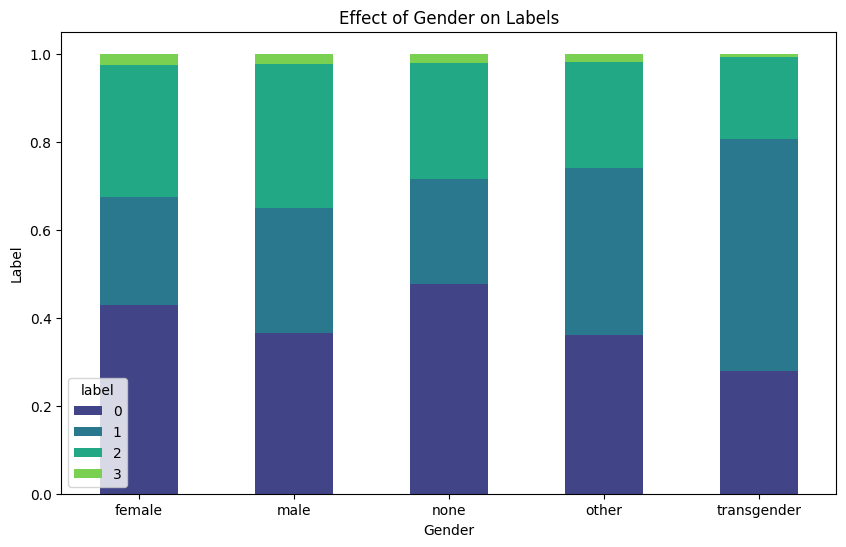

In [200]:
gender_label = pd.crosstab(df["gender"], df["label"], normalize="index")
gender_label.plot(kind="bar", stacked= True, figsize= (10,6), color=sns.color_palette("viridis", 4))
plt.title("Effect of Gender on Labels")
plt.xlabel("Gender")
plt.ylabel("Label")
plt.xticks(rotation=0)
plt.show()

#### Gender shows variation in label distribution, so it is a useful predictive feature.

#### Female and “none” categories are dominated by label 0.

#### Male and “other” have a more balanced mix of labels 0 and 1.

#### Transgender category shows a higher proportion of label 1, making it distinct.

#### Labels 2 and 3 are very rare across all genders → indicates class imbalance.

#### Smaller groups (like transgender) may lead to model bias or instability.

#### Overall, gender is informative but requires careful handling for imbalance and fairness.

# DATA PREPROCESSING 

## HANDLE MISSING VALUES

In [201]:
missing_col =["race", "religion", "gender"]
for col in missing_col:
    df[col]=df[col].fillna("none")
    X_test[col]= X_test[col].fillna("none")
df["comment"]=df["comment"].fillna("empty comment")   

In [202]:
X_test.isnull().mean()*100

created_date    0.0
post_id         0.0
emoticon_1      0.0
emoticon_2      0.0
emoticon_3      0.0
upvote          0.0
downvote        0.0
if_1            0.0
if_2            0.0
race            0.0
religion        0.0
gender          0.0
disability      0.0
comment         0.0
dtype: float64

In [203]:
df.isnull().mean()*100

created_date    0.0
post_id         0.0
emoticon_1      0.0
emoticon_2      0.0
emoticon_3      0.0
upvote          0.0
downvote        0.0
if_1            0.0
if_2            0.0
race            0.0
religion        0.0
gender          0.0
disability      0.0
comment         0.0
label           0.0
dtype: float64

## FEATURE ENGINEERING 

In [204]:
df["comment_length"] = df["comment"].str.len()
df["word_count"] = df["comment"].apply(lambda x: len(str(x).split()))
df["avg_word_length"] = df["comment_length"]/ df["word_count"]

X_test["comment_length"] = X_test["comment"].str.len()
X_test["word_count"] = X_test["comment"].apply(lambda x: len(str(x).split()))
X_test["avg_word_length"] = X_test["comment_length"]/ (X_test["word_count"]+ 1)


X_test.columns



Index(['created_date', 'post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3',
       'upvote', 'downvote', 'if_1', 'if_2', 'race', 'religion', 'gender',
       'disability', 'comment', 'comment_length', 'word_count',
       'avg_word_length'],
      dtype='object')

In [205]:
df["net_votes"] =df["upvote"] - df["downvote"]
df["total_votes"] =df["upvote"] + df["downvote"]
df["vote_ratio"] =df["upvote"]/(df["downvote"]+1)

X_test["net_votes"] =X_test["upvote"] - X_test["downvote"]
X_test["total_votes"] =X_test["upvote"] + X_test["downvote"]
X_test["vote_ratio"] =X_test["upvote"]/(X_test["downvote"]+1)
X_test.head(2)


,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,comment_length,word_count,avg_word_length,net_votes,total_votes,vote_ratio
0,2024-02-08 13:13:27.998156+00:00,72,2,0,0,4,1,0,10,none,none,none,False,Canada is being run by someone with the mental...,72,12,5.538462,3,5,2.0
1,2024-03-01 23:33:25.547123+00:00,123,0,0,0,0,0,0,10,none,none,none,False,And your comment is left-wing drivel,36,6,5.142857,0,0,0.0


In [206]:
df["emoticon_sum"] = df["emoticon_1"] +df["emoticon_2"]+df["emoticon_3"]
df["if_sum"] = df["if_1"]+ df["if_2"]

X_test["emoticon_sum"] = X_test["emoticon_1"] +X_test["emoticon_2"]+X_test["emoticon_3"]
X_test["if_sum"] = X_test["if_1"]+ X_test["if_2"]

In [207]:
df['created_date'] = pd.to_datetime(df['created_date'])
df['year'] = df['created_date'].dt.year
df['month'] = df['created_date'].dt.month
df['day_of_week'] = df['created_date'].dt.dayofweek 
df['hour'] = df['created_date'].dt.hour

X_test['created_date'] = pd.to_datetime(X_test['created_date'])
X_test['year'] = X_test['created_date'].dt.year
X_test['month'] = X_test['created_date'].dt.month
X_test['day_of_week'] = X_test['created_date'].dt.dayofweek 
X_test['hour'] = X_test['created_date'].dt.hour
X_test.head(2)

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,...,avg_word_length,net_votes,total_votes,vote_ratio,emoticon_sum,if_sum,year,month,day_of_week,hour
0,2024-02-08 13:13:27.998156+00:00,72,2,0,0,4,1,0,10,none,...,5.538462,3,5,2.0,2,10,2024,2,3,13
1,2024-03-01 23:33:25.547123+00:00,123,0,0,0,0,0,0,10,none,...,5.142857,0,0,0.0,0,10,2024,3,4,23


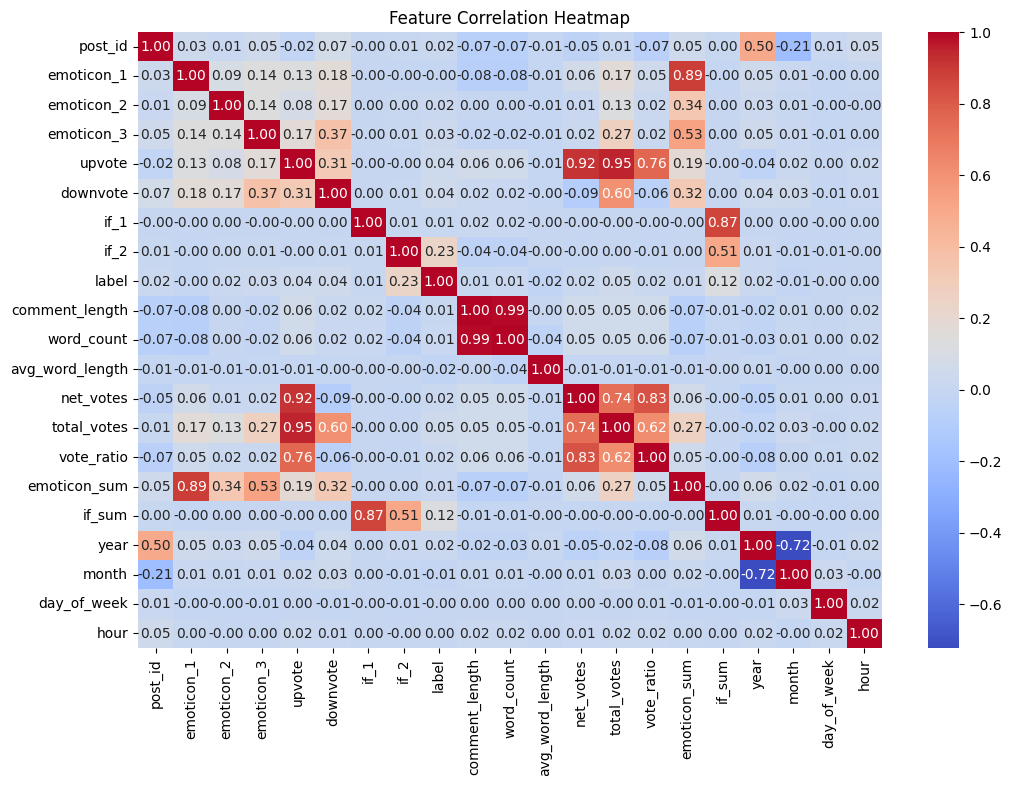

In [208]:
numeric_col = df.select_dtypes(include=['number'])
plt.figure(figsize=(12, 8))
sns.heatmap(numeric_col.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Feature Correlation Heatmap")
plt.show()

#### The heatmap indicates strong multicollinearity among engineered features, especially in vote-based features (upvote, net_votes, total_votes, vote_ratio) and text features (comment_length and word_count), showing redundancy. Derived features like emotion_sum and if_sum are also highly correlated with their components.

#### Most features have weak correlation with the target variable, suggesting non-linear relationships. Therefore, models like XGBoost, LightGBM, and ensemble methods are more suitable as they handle multicollinearity well and capture complex patterns effectively. Feature selection can further improve efficiency by removing redundant features.

In [209]:
df.columns

Index(['created_date', 'post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3',
       'upvote', 'downvote', 'if_1', 'if_2', 'race', 'religion', 'gender',
       'disability', 'comment', 'label', 'comment_length', 'word_count',
       'avg_word_length', 'net_votes', 'total_votes', 'vote_ratio',
       'emoticon_sum', 'if_sum', 'year', 'month', 'day_of_week', 'hour'],
      dtype='object')

In [210]:
df.shape

(198000, 27)

## HANDLE OUTLIERS

In [211]:
log_cols =["upvote", "downvote", "total_votes", "comment_length", "emoticon_sum","if_sum","if_sum","if_1","if_2"]
for col in log_cols:
    df[col] = np.log1p(df[col])
    X_test[col]= np.log1p(X_test[col])
    
df["net_votes"] = np.sign(df["net_votes"]) * np.log1p(np.abs(df["net_votes"]))
X_test["net_votes"] = np.sign(X_test["net_votes"])*np.log1p(np.abs(X_test["net_votes"]))
df["net_votes"].unique()

array([-0.69314718,  1.94591015,  0.        ,  1.79175947,  1.60943791,
        0.69314718,  1.09861229, -2.07944154,  1.38629436,  2.48490665,
       -1.09861229,  2.19722458,  2.39789527, -1.79175947,  3.13549422,
        3.4339872 ,  2.7080502 , -1.38629436,  2.07944154, -2.39789527,
        2.63905733,  4.24849524,  3.58351894,  3.09104245, -1.60943791,
        2.99573227,  3.25809654, -2.77258872,  2.56494936,  3.8286414 ,
        2.89037176,  2.30258509,  2.94443898, -1.94591015, -2.30258509,
        2.83321334, -2.63905733,  3.4657359 ,  3.17805383,  3.55534806,
        3.04452244,  3.33220451,  3.61091791,  2.77258872, -2.56494936,
       -3.4339872 ,  3.49650756,  3.91202301,  3.29583687, -3.25809654,
        3.40119738,  3.93182563,  3.52636052,  3.21887582,  3.36729583,
        3.78418963, -2.19722458,  3.71357207,  3.66356165, -2.89037176,
        3.63758616,  3.95124372, -2.48490665, -3.13549422, -2.83321334,
        4.52178858,  3.8918203 ,  4.41884061, -3.04452244,  4.57

In [212]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)
X_test.replace([np.inf, -np.inf], np.nan, inplace=True)
num_cols = ["upvote", "downvote", "total_votes", "comment_length", "emoticon_sum","if_sum", "vote_ratio"]
median_val = df[num_cols].median()
df[num_cols] = df[num_cols].fillna(median_val)
X_test[num_cols] = X_test[num_cols].fillna(median_val)

In [213]:
df.isnull().sum()

created_date       0
post_id            0
emoticon_1         0
emoticon_2         0
emoticon_3         0
upvote             0
downvote           0
if_1               0
if_2               0
race               0
religion           0
gender             0
disability         0
comment            0
label              0
comment_length     0
word_count         0
avg_word_length    0
net_votes          0
total_votes        0
vote_ratio         0
emoticon_sum       0
if_sum             0
year               0
month              0
day_of_week        0
hour               0
dtype: int64

In [214]:
df["avg_word_length"] = df["avg_word_length"].clip(upper=20)
X_test["avg_word_length"] = X_test["avg_word_length"].clip(upper=20)

In [215]:
df["vote_ratio"] = df["upvote"] / (df["upvote"] + df["downvote"] + 1)
X_test["vote_ratio"] = X_test["upvote"] / (X_test["upvote"] + X_test["downvote"] + 1)

In [216]:
df.describe()

,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,label,comment_length,...,avg_word_length,net_votes,total_votes,vote_ratio,emoticon_sum,if_sum,year,month,day_of_week,hour
count,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,...,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000
mean,68.447429,0.279768,0.048338,0.121071,0.835155,0.280427,0.490491,2.015503,0.793965,5.298194,...,5.813149,0.612773,0.967068,0.295344,0.222818,1.135518,2023.416975,5.956101,3.069354,12.128833
std,27.948390,1.023234,0.258477,0.481013,0.860478,0.548601,0.837056,0.483283,0.979808,0.988456,...,1.061904,0.974845,0.916039,0.259797,0.456010,0.163734,0.564834,3.460970,2.059938,8.082283
min,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.386294,0.000000,0.693147,...,1.000000,-4.406719,0.000000,0.000000,0.000000,0.869742,2022.000000,1.000000,0.000000,0.000000
25%,39.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.609438,0.000000,4.634729,...,5.363636,0.000000,0.000000,0.000000,0.000000,0.959135,2023.000000,3.000000,1.000000,4.000000
50%,72.000000,0.000000,0.000000,0.000000,0.693147,0.000000,0.000000,1.945910,0.000000,5.356586,...,5.700000,0.693147,0.693147,0.397800,0.000000,1.162283,2023.000000,5.000000,3.000000,13.000000
75%,72.000000,0.000000,0.000000,0.000000,1.386294,0.693147,1.609438,2.397895,2.000000,6.040255,...,6.066667,1.386294,1.609438,0.523495,0.000000,1.223156,2024.000000,9.000000,5.000000,20.000000
max,129.000000,47.000000,11.000000,17.000000,5.308268,4.682131,7.528869,7.514255,3.000000,7.545918,...,20.000000,5.087596,5.488938,0.835396,4.110874,2.147353,2024.000000,12.000000,6.000000,23.000000


## ENCODING 

In [217]:

bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] =df[bool_cols].astype(int)
X_test[bool_cols] =X_test[bool_cols].astype(int)
df.head(5)

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,...,avg_word_length,net_votes,total_votes,vote_ratio,emoticon_sum,if_sum,year,month,day_of_week,hour
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0.000000,0.693147,0.0,2.397895,none,...,5.900000,-0.693147,0.693147,0.000000,0.000000,1.223156,2024,1,3,8
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,1.945910,0.000000,0.0,1.609438,none,...,5.854545,1.945910,1.945910,0.660546,0.000000,0.959135,2024,3,6,21
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0.000000,0.000000,0.0,2.397895,none,...,5.646617,0.000000,0.000000,0.000000,1.098612,1.223156,2024,4,2,20
3,2023-05-28 22:00:14.214527+00:00,39,0,0,0,1.791759,0.000000,0.0,2.397895,none,...,6.066667,1.791759,1.791759,0.641803,0.000000,1.223156,2023,5,6,22
4,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0.000000,0.000000,0.0,2.397895,none,...,6.350000,0.000000,0.000000,0.000000,0.000000,1.223156,2023,9,5,23


### Encoding the comments 

In [218]:
y_train=df['label']
X_train = df.drop(columns="label")

X_train["comment"] = X_train["comment"].str.lower()
X_test["comment"]=X_test["comment"].str.lower()

X_test_ = X_test



In [219]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198000 entries, 0 to 197999
Data columns (total 26 columns):
 #   Column           Non-Null Count   Dtype              
---  ------           --------------   -----              
 0   created_date     198000 non-null  datetime64[ns, UTC]
 1   post_id          198000 non-null  int64              
 2   emoticon_1       198000 non-null  int64              
 3   emoticon_2       198000 non-null  int64              
 4   emoticon_3       198000 non-null  int64              
 5   upvote           198000 non-null  float64            
 6   downvote         198000 non-null  float64            
 7   if_1             198000 non-null  float64            
 8   if_2             198000 non-null  float64            
 9   race             198000 non-null  object             
 10  religion         198000 non-null  object             
 11  gender           198000 non-null  object             
 12  disability       198000 non-null  int64              
 13 

In [220]:
text_col= "comment"

cat_col = ["race", "religion", "gender"]


numeric_cols = ['emoticon_1', 'emoticon_2', 'emoticon_3','upvote', 'downvote', 'if_1',
'if_2','comment_length', 'word_count', 'avg_word_length','net_votes', 'total_votes', 
'vote_ratio','emoticon_sum', 'if_sum'
]


## SCALING
### ColumnTransformer

In [221]:
preprocessor = ColumnTransformer(
    transformers=[
        ('tfidf', TfidfVectorizer(max_features= 10000, stop_words ='english', ngram_range=(1,3), min_df=3, max_df = 0.9), text_col),
        ('scaler', MaxAbsScaler(), numeric_cols),
        ('encode', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_col)
    ]
)

# MODEL TRAINING

### MODELS
#### 1. Logistic Regression
#### 2. Support Vector Machine(SVM)
#### 3. LightGBM
#### 4. XGBClassifier
#### 5. RandomForest






In [222]:
X_train1,X_test1,y_train1,y_test1 = train_test_split(
    X_train, y_train , test_size = 0.2, stratify=y_train, random_state= 42
)

In [223]:
X_test_ = X_test_.reindex(columns=X_train.columns, fill_value=0)

In [224]:
for df in [X_train1, X_test1, X_train, X_test_]:
    df["comment"] = df["comment"].fillna("").astype(str)

In [225]:
X_train = X_train.fillna(0)
X_test_ = X_test_.fillna(0)
X_train1.isna().sum().sort_values(ascending=False).head(20)

created_date       0
post_id            0
emoticon_1         0
emoticon_2         0
emoticon_3         0
upvote             0
downvote           0
if_1               0
if_2               0
race               0
religion           0
gender             0
disability         0
comment            0
comment_length     0
word_count         0
avg_word_length    0
net_votes          0
total_votes        0
vote_ratio         0
dtype: int64


## Logistic regression


In [ ]:
pipeline = Pipeline(
    [
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter = 2000,solver="saga", class_weight="balanced", n_jobs=-1))
    ]
)

In [ ]:
pipeline.fit(X_train1, y_train1)
y_test1_pred = pipeline.predict(X_test1)

print("Accuracy:", accuracy_score(y_test1, y_test1_pred))
print(classification_report(y_test1, y_test1_pred))


### Accuracy: 0.8873232323232323
              precision    recall  f1-score   support

           0       0.98      0.92      0.95     22835
           1       0.66      0.82      0.73      3183
           2       0.86      0.85      0.86     12488
           3       0.43      0.72      0.54      1094

    accuracy                           0.89     39600
####   macro avg       0.73      0.83      0.77     39600
#### weighted avg       0.90      0.89      0.89     39600

### INSIGHTS

#### Accuracy = 0.887 (~89%)
####  Strong model overall

### Class 0:
#### Model is excellent but slightly drop in recall as do some misclassification. Overally model performs well for class 0 (dominant class due to high density data available for class 0)

### Class 1:
#### As recall is 0.82 bt precision is lower than  that (0.66) it indicates that the model is overpredicting class 1.

### Class 2:
#### Both precision and the recall are nearly same indicating Clear Feature Separability

### Class 3:
#### Precision(0.43) is lower than the recall(0.72) indicating model is too aggressive for class 3(due to imbalance class and use of class weighting = balanced) 

#### There is a huge gap between macro F1(0.77) and weighted F1(0.89) indicating weighted metrics overestimate performance due to dominance of majority class


### Overall , the model is sensitive to minority class











In [ ]:
pipeline.fit(X_train, y_train)
y_test_pred = pipeline.predict(X_test_)

submission = pd.DataFrame({
    "ID": range(1, X_test_.shape[0] + 1),
    "target": y_test_pred
})

submission.to_csv("submission.csv", index=False)


## SVM

In [ ]:

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearSVC(C= 0.5,class_weight="balanced"))
])

pipeline.fit(X_train1, y_train1)
y_test1_pred = pipeline.predict(X_test1)

print("Accuracy:", accuracy_score(y_test1, y_test1_pred))
print(classification_report(y_test1, y_test1_pred))

### Accuracy: 0.8954040404040404
              precision    recall  f1-score   support

           0       0.98      0.93      0.95     22835
           1       0.69      0.81      0.75      3183
           2       0.87      0.87      0.87     12488
           3       0.46      0.69      0.55      1094

    accuracy                           0.90     39600

####   macro avg       0.75      0.83      0.78     39600
#### weighted avg       0.91      0.90      0.90     39600


#### The model achieves high overall accuracy (~89.5%), indicating good general performance.

#### Class 0 performs best with very high precision (0.98) and strong recall (0.93), showing the model predicts the majority class very well.

#### Class 2 also shows strong performance with balanced precision and recall (~0.87), indicating stable predictions.

#### Class 1 has moderate performance, with lower precision (0.69) but good recall (0.81), meaning the model captures most true cases but with some false positives.

#### Class 3 performs the weakest, with low precision (0.46) but relatively better recall (0.69), indicating difficulty in correctly identifying this minority class.

#### The difference between macro avg (0.78) and weighted avg (0.90) highlights class imbalance, where dominant classes influence overall performance.

#### So the SVM model performs well overall but struggles with minority classes, especially class 3.


In [ ]:
pipeline.fit(X_train, y_train)
y_test_pred = pipeline.predict(X_test_)

submission = pd.DataFrame({
    "ID": range(1, X_test_.shape[0] + 1),
    "target": y_test_pred
})

submission.to_csv("submission.csv", index=False)


## LightGBM

In [ ]:
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LGBMClassifier(
        n_estimators=200,
        learning_rate=0.1,
        class_weight="balanced"
    ))
])

In [ ]:
pipeline.fit(X_train1, y_train1)
y_test1_pred = pipeline.predict(X_test1)

print("Accuracy:", accuracy_score(y_test1, y_test1_pred))
print(classification_report(y_test1, y_test1_pred))


### Accuracy: 0.8958585858585859
####               precision    recall  f1-score   support

           0       0.98      0.94      0.96     22835
           1       0.68      0.86      0.76      3183
           2       0.90      0.83      0.86     12488
           3       0.41      0.79      0.54      1094

    accuracy                           0.90     39600
####   macro avg       0.74      0.86      0.78     39600
#### weighted avg       0.91      0.90      0.90     39600


#### The model achieves high accuracy (~89.6%), indicating strong overall performance.

#### Class 0 shows excellent performance with very high precision (0.98) and recall (0.94), meaning it is predicted very reliably.

#### Class 2 also performs well, with balanced precision (0.90) and recall (0.83).

#### Class 1 has moderate performance, with good recall (0.86) but lower precision (0.68), indicating some false positives.

#### Class 3 remains the weakest, with very low precision (0.41) but high recall (0.79), meaning the model over-predicts this class.

#### The gap between macro avg (0.78) and weighted avg (0.90) again highlights class imbalance in the dataset.

#### LightGBM performs well overall and handles complex patterns effectively, it struggles with minority class precision (especially class 3)


In [ ]:
pipeline.fit(X_train, y_train)
y_test_pred = pipeline.predict(X_test_)

submission = pd.DataFrame({
    "ID": range(1, X_test_.shape[0] + 1),
    "target": y_test_pred
})

submission.to_csv("submission.csv", index=False)


## XGBClassifier

In [ ]:
pipeline = Pipeline([
      ("preprocessor" , preprocessor),
      ("model",XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
      )
])

In [ ]:
pipeline.fit(X_train1,y_train1)
y_test1_pred= pipeline.predict(X_test1)

print("Accuracy:" , accuracy_score(y_test1, y_test1_pred))
print(classification_report(y_test1, y_test1_pred ))





### Accuracy: 0.8987373737373737
####       precision                recall                 f1-score                support

           0       0.97      0.95      0.96     22835
           1       0.74      0.73      0.73      3183
           2       0.82      0.90      0.86     12488
           3       0.79      0.28      0.41      1094

    accuracy                           0.90     39600
####   macro avg       0.83      0.71      0.74     39600
#### weighted avg       0.90      0.90      0.90     39600

#### The XGBClassifier achieves high accuracy (~89.9%), showing strong overall performance.

#### Class 0 performs the best, with very high precision (0.97) and recall (0.95), indicating reliable predictions.

#### Class 2 also performs well, especially with high recall (0.90), showing good detection of this class.

#### Class 1 has moderate and balanced performance (precision ≈ recall ≈ 0.73).

#### Class 3 performs poorly, with very low recall (0.28) despite high precision (0.79), meaning many actual cases are missed.

#### The gap between macro avg (0.74) and weighted avg (0.90) indicates class imbalance.

#### It also struggle with minority class(3)


In [ ]:
pipeline.fit(X_train, y_train)
y_test_pred = pipeline.predict(X_test_)

submission = pd.DataFrame({
    "ID": range(1, X_test_.shape[0] + 1),
    "target": y_test_pred
})

submission.to_csv("submission.csv", index=False)

## Random Forest

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('tfidf', TfidfVectorizer(max_features= 5000, stop_words ='english', ngram_range=(1,2), min_df=3, max_df = 0.9), text_col),
        ('scaler', MinMaxScaler(), numeric_cols),
        ('encode', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_col)
        # ('dummy', 'passthrough', dummy_cols)
    ]
)

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", MultinomialNB())
])



In [ ]:
pipeline.fit(X_train1, y_train1)
y_test1_pred = pipeline.predict(X_test1)

print("Accuracy:", accuracy_score(y_test1, y_test1_pred))
print(classification_report(y_test1, y_test1_pred))





### Accuracy: 0.7458838383838384
####              precision    recall  f1-score   support

           0       0.75      0.91      0.82     22835
           1       0.57      0.70      0.63      3183
           2       0.81      0.52      0.63     12488
           3       0.76      0.07      0.12      1094

    accuracy                           0.75     39600
####   macro avg       0.72      0.55      0.55     39600
#### weighted avg       0.76      0.75      0.73     39600


#### The model achieves moderate accuracy (~74.6%), lower than other models like XGBoost and LightGBM.

#### Class 0 performs well, with high recall (0.91) and good F1-score (0.82), indicating strong detection of the majority class.

#### Class 1 shows moderate performance, with balanced but lower precision and recall (~0.57–0.70).

#### Class 2 has high precision (0.81) but low recall (0.52), meaning many actual instances are missed.

#### Class 3 performs very poorly, with extremely low recall (0.07), indicating the model almost fails to detect this class.

#### The macro average (0.55) is significantly lower than the weighted average (0.73), highlighting severe class imbalance impact.

In [ ]:
pipeline.fit(X_train, y_train)
y_test_pred = pipeline.predict(X_test_)


submission = pd.DataFrame({
    "ID": range(1, X_test_.shape[0] + 1),
    "target": y_test_pred
})

submission.to_csv("submission.csv", index=False)

# HYPERTUNING

### From the above model training I found that 


### 1.XGClassifier : 0.8987
### 2.LightGBM : 0.8958
### 3.SVM : 879

### To further improve performance, we perform hyperparameter tuning on these models using
## RandomizedSearchCV.

### We use RandomizedSearch instead of GridSearch because:

### * It is faster
### * It explores a wide range of parameters efficiently








### XGBoosting hypertune

In [ ]:
pipeline_xgb = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(eval_metric='logloss'))
])

param_grid_xgb = {
    'model__n_estimators': [200, 300],
    'model__max_depth': [4, 6, 8],
    'model__learning_rate': [0.03, 0.05, 0.1],
    'model__subsample': [0.8, 1],
    'model__colsample_bytree': [0.8, 1]
}

random_xgb = RandomizedSearchCV(
    pipeline_xgb,
    param_distributions=param_grid_xgb,
    n_iter=10,
    cv=3,
    scoring='accuracy',
    verbose=2,
    n_jobs=-1,
    random_state=42
)

random_xgb.fit(X_train1, y_train1)

print("Best XGB Params:", random_xgb.best_params_)
print("Best XGB Score:", random_xgb.best_score_)

best_xgb = random_xgb.best_estimator_



#### Best XGB Params: {
#### 'subsample': 0.8,
#### 'n_estimators': 300,
#### 'learning_rate': 0.1,
#### 'colsample_bytree': 0.8}

### Best XGB Score: 0.9063383838383839

### Logistic Regression

In [ ]:
pipeline_lr = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

param_grid_lr = {
    'model__C': [0.01, 0.1, 1, 5, 10],
    'model__penalty': ['l2'],   # safe option
    'model__solver': ['lbfgs']  # stable for multi-class
}

random_lr = RandomizedSearchCV(
    pipeline_lr,
    param_distributions=param_grid_lr,
    n_iter=5,
    cv=3,
    scoring='accuracy',
    verbose=2,
    n_jobs=-1,
    random_state=42
)

random_lr.fit(X_train1, y_train1)

print("Best LR Params:", random_lr.best_params_)
print("Best LR Score:", random_lr.best_score_)

best_lr = random_lr.best_estimator_

#### Best LR Params: {
#### 'solver': 'lbfgs',
#### 'penalty': 'l2',
#### 'C': 5}

### Best LR Score: 0.799324494949495

### LightGBM Hypertune

In [ ]:
pipeline_lgbm = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LGBMClassifier())
])

param_grid_lgbm = {
    'model__n_estimators': [200, 300],
    'model__num_leaves': [31, 50, 70],
    'model__learning_rate': [0.03, 0.05, 0.1],
    'model__subsample': [0.8, 1]
}

random_lgbm = RandomizedSearchCV(
    pipeline_lgbm,
    param_distributions=param_grid_lgbm,
    n_iter=10,
    cv=3,
    scoring='accuracy',
    verbose=2,
    n_jobs=-1,
    random_state=42
)

random_lgbm.fit(X_train1, y_train1)

print("Best LGBM Params:", random_lgbm.best_params_)
print("Best LGBM Score:", random_lgbm.best_score_)

best_lgbm = random_lgbm.best_estimator_

#### Best LGBM Params: {
#### 'subsample': 0.8, 
#### 'num_leaves': 70, 
#### 'n_estimators': 200, 
#### 'learning_rate': 0.05}
	
### Best LGBM Score: 0.9096717171717171

### SVM

In [ ]:
pipeline_svm = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearSVC())
])

param_grid_svm = {
    'model__C': [0.1, 1, 5, 10]
}

random_svm = RandomizedSearchCV(
    pipeline_svm,
    param_distributions=param_grid_svm,
    n_iter=4,
    cv=3,
    scoring='accuracy',
    verbose=2,
    n_jobs=-1,
    random_state=42
)

random_svm.fit(X_train1, y_train1)

print("Best SVM Params:", random_svm.best_params_)
print("Best SVM Score:", random_svm.best_score_)

best_svm = random_svm.best_estimator_

#### Best SVM Params: {
#### 'C': 5}

### Best SVM Score: 0.8757449494949494

# MODEL COMPARISION

In [ ]:
print("Logistic Regression:", random_lr.best_score_)
print("XGBoost:", random_xgb.best_score_)
print("LightGBM:", random_lgbm.best_score_)
print("SVM:", random_svm.best_score_)

#### Logistic Regression: 0.799324494949495
#### XGBoost: 0.9063383838383839
#### LightGBM: 0.9096717171717171
#### SVM: 0.8757449494949494

In [ ]:
models = {
    "Logistic": best_lr,
    "SVM": best_svm,
    "XGBoost": best_xgb,
    "LightGBM": best_lgbm
}

for name, model in models.items():
    y_test_pred = model.predict(X_test1)
    acc = accuracy_score(y_test1, y_test_pred)
    print(f"{name}: {acc}")

#### Logistic: 0.7881565656565657
#### SVM: 0.8752272727272727
#### XGBoost: 0.9102020202020202
#### LightGBM: 0.9137626262626263


#### From the above accuracy score we can conclude that LightGBM is working best for our dataset as it has the highest accuracy score on validation data i.e . 0.9137626262626263

#### So i will train the test data for LightGBM model and do the final submission 



# FINAL SUBMISSION 


### Model : LightGBM
### Best Parameter:{
#### 'subsample': 0.8, 
#### 'num_leaves': 70, 
#### 'n_estimators': 200, 
#### 'learning_rate': 0.05
#### } 



In [ ]:
final_lgbm = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LGBMClassifier(
        n_estimators=200,
        num_leaves=70,
        learning_rate=0.05,
        subsample=0.8
    ))
])

In [ ]:
final_lgbm.fit(X_train1, y_train1)
y_test1_pred = final_lgbm.predict(X_test1)


print("Accuracy:", accuracy_score(y_test1, y_test1_pred))
print(classification_report(y_test1, y_test1_pred))





### Accuracy: 0.9141666666666667
              precision    recall  f1-score   support

           0       0.98      0.95      0.96     22835
           1       0.77      0.79      0.78      3183
           2       0.85      0.92      0.88     12488
           3       0.74      0.50      0.60      1094

    accuracy                           0.91     39600
###   macro avg       0.84      0.79      0.81     39600
### weighted avg       0.92      0.91      0.91     39600

#### After hyperparameter tuning, LightGBM achieves the best accuracy (~91.4%), outperforming all other models.

#### Class 0 shows excellent performance with very high precision (0.98) and recall (0.95).

#### Class 2 performs strongly, with high recall (0.92) and good overall balance.

#### Class 1 shows improved and balanced performance (precision 0.77, recall 0.79).

#### Class 3 performance improves compared to previous models, with better precision (0.74) and recall (0.50), though recall is still moderate.

#### The lower recall for class 3 indicates the model is conservative, predicting this class only when highly confident.

#### The gap between macro avg (0.81) and weighted avg (0.91) still indicates class imbalance, but overall performance is improved. 

In [ ]:
final_lgbm.fit(X_train, y_train)
y_final= final_lgbm.predict(X_test_)

submission = pd.DataFrame({
    "ID": range(1, X_test_.shape[0] + 1),
    "target": y_final
})

submission.to_csv("submission.csv", index=False)

### Model : XGBClassifier
### Parameters: {
#### 'subsample': 0.8,
#### 'n_estimators': 300,
#### 'learning_rate': 0.1,
#### 'colsample_bytree': 0.8}


In [ ]:
final_xgb = Pipeline([
('preprocessor', preprocessor),
('model',XGBClassifier(
   subsample= 0.8,
   n_estimators= 300,
   learning_rate= 0.1,
   colsample_bytree= 0.8,
   random_state=42,
   n_jobs=-1,))
])

In [ ]:
final_xgb.fit(X_train1, y_train1)
y_final_xgb = final_xgb.predict(X_test1)

print("Accuracy:", accuracy_score(y_test1, y_final_xgb))
print(classification_report(y_test1, y_final_xgb))




In [ ]:
y_final_xgb = final_xgb.predict(X_test1)

print("Accuracy:", accuracy_score(y_test1, y_final_xgb))
print(classification_report(y_test1, y_final_xgb))

#### Accuracy: 0.9086616161616161
              precision    recall  f1-score   support

           0       0.98      0.95      0.96     22835
           1       0.77      0.75      0.76      3183
           2       0.84      0.92      0.88     12488
           3       0.75      0.40      0.52      1094

    accuracy                           0.91     39600
####   macro avg       0.83      0.75      0.78     39600
#### weighted avg       0.91      0.91      0.91     39600

#### The tuned XGBClassifier achieves high accuracy (~90.9%), performing slightly below LightGBM.

#### Class 0 performs excellently, with very high precision (0.98) and recall (0.95).

#### Class 2 shows strong performance, with high recall (0.92) and good balance overall.

#### Class 1 has moderate and stable performance (precision 0.77, recall 0.75).

#### Class 3 remains challenging, with good precision (0.75) but low recall (0.40), meaning many actual cases are missed.

#### The lower recall for class 3 indicates conservative predictions, similar to LightGBM but slightly weaker.

#### The gap between macro avg (0.78) and weighted avg (0.91) reflects class imbalance.

### Model : Logistic Regression
### Parameter{
#### 'solver': 'lbfgs',
#### 'penalty': 'l2',
#### 'C': 5}




In [ ]:
final_lr= Pipeline([
   ('preprocessor', preprocessor),
   ('model',LogisticRegression(
          solver= 'lbfgs',
          penalty= 'l2',
          C= 5,
          max_iter = 1000,
          n_jobs = -1

))

])

In [ ]:
final_lr.fit(X_train1, y_train1)
y_final_lr = final_lr.predict(X_test1)

print("Accuracy:", accuracy_score(y_test1, y_final_xgb))
print(classification_report(y_test1, y_final_lr))



#### Accuracy: 0.9086616161616161
              precision    recall  f1-score   support

           0       0.97      0.94      0.96     22835
           1       0.77      0.74      0.75      3183
           2       0.85      0.91      0.88     12488
           3       0.68      0.51      0.58      1094

    accuracy                           0.90     39600
####   macro avg       0.81      0.78      0.79     39600
#### weighted avg       0.91      0.90      0.90     39600

#### The model achieves high accuracy (~90.9%), comparable to XGBoost.

#### Class 0 performs very well, with high precision (0.97) and recall (0.94).

#### Class 2 shows strong and balanced performance (precision 0.85, recall 0.91).

#### Class 1 has moderate performance (precision 0.77, recall 0.74).

#### Class 3 performs better than some models, with balanced precision (0.68) and recall (0.51), though still not optimal.

#### The macro avg (0.79) vs weighted avg (0.90) indicates class imbalance, but performance is relatively stable across classes.

## ENSEMBLE

### To further improve model performance, an ensemble approach was applied by combining XGBClassifier, LightGBM, and Logistic Regression. XGBoost and LightGBM showed similar high accuracy and strong performance on majority classes, while Logistic Regression contributed better balance, particularly improving predictions for the minority class (class 3). By integrating these models, the ensemble leverages the strengths of both non-linear boosting algorithms and a linear model, resulting in more robust and generalized predictions. This approach helps in handling class imbalance more effectively and improves overall model stability compared to individual models.

In [254]:
voting_model = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(
            solver='lbfgs',
            penalty='l2',
            C=5,
            max_iter=2000,
            n_jobs=-1
        )),
        ('lgbm', LGBMClassifier(
            n_estimators=400,
            num_leaves=100,
            learning_rate=0.05,
            subsample=0.8,
            random_state=42,
            class_weight = {
                 0:1,
                 1:1.5,
                 2:1,
                 3:2.5 
            }   

        )),
        ('xgb', XGBClassifier(
            subsample=0.8,
            n_estimators=500,
            learning_rate=0.1,
            colsample_bytree=0.8,
            n_jobs=-1,
            random_state=42
        ))
    ],
    voting='soft',
    weights=[2, 3, 1] 
)

In [255]:
final_model = Pipeline([
    ('preprocessor', preprocessor),
    ('voting', voting_model)
])

In [256]:
final_model.fit(X_train1, y_train1)
y_test_final= final_model.predict(X_test1)

print("Accuracy:", accuracy_score(y_test1, y_test_final))
print("Macro F1:", f1_score(y_test1, y_test_final, average='macro'))

print(classification_report(y_test1, y_test_final))






### Accuracy: 0.9161616161616162
### Macro F1: 0.8193411508353813
              precision    recall  f1-score   support

           0       0.98      0.95      0.96     22835
           1       0.77      0.79      0.78      3183
           2       0.86      0.92      0.89     12488
           3       0.72      0.58      0.64      1094

    accuracy                           0.92     39600
###   macro avg       0.83      0.81      0.82     39600
### weighted avg       0.92      0.92      0.92     39600

In [258]:
final_model.fit(X_train, y_train)
y_final = final_model.predict(X_test_)

submission = pd.DataFrame({
     "ID": range(1, X_test_.shape[0] + 1),
     "target": y_final


})
submission.to_csv("submission.csv", index=False)


